In [ ]:
"""
build_master.py — Run in Google Colab
Creates a master table based on SwimSafe E. coli sample dates,
then joins rainfall and flow data. Nulls where no data exists.
- All windows (24h, 48h, 72h, 96h, 120h, 144h) are INCLUSIVE of day0 (T).
  e.g. prior48h = days T, T-1, T-2.
- Rainfall windows: SUM (total accumulated rainfall) AND MAX (peak daily rainfall in window)
- Flow windows: MAX (peak flow in the window) AND SUM (total flow in window)
- Site Mapping.csv - Manual Mapping File to map between ecoli sites and rainfall/flow sites
"""

import pandas as pd
import numpy as np

DRIVE     = "/safe_to_swim_MINZ_2026/scripts/Visualisation" #Change the path as needed
SWIM_FILE = DRIVE + "swim_spot_data.xlsx"
RAIN_FILE = DRIVE + "Rainfall_hourly.csv"
FLOW_FILE = DRIVE + "Flow Max.csv"
SITE_MAP  = DRIVE + "site_mapping.csv"
OUTPUT    = DRIVE + "master_water_quality.xlsx"

PARAMS    = "coli"

# ── 1. Swim site list ─────────────────────────────────────────────────────────
meta       = pd.read_excel(SWIM_FILE, sheet_name="Site location metadata")
swim_sites = sorted(meta["site_name"].dropna().str.strip().unique())
print(f"Swim sites: {len(swim_sites)}")

# ── 2. Load SwimSafe E. coli ──────────────────────────────────────────────────
ss = pd.read_excel(SWIM_FILE, sheet_name="Recreational Water Quality")
ss = ss[ss["parameter"].str.contains(PARAMS, case=False, na=False)]
ss = ss[ss["sitename"].str.strip().isin(swim_sites)]
ss["date"] = pd.to_datetime(ss["date"]).dt.normalize()
ss = ss[["sitename", "date", "parameter", "value", "units"]].copy()
ss.columns = ["sitename", "date", "parameter", "ecoli_value", "ecoli_units"]
ss["ecoli_source"] = "SwimSafe"
ss["ecoli_value"] = pd.to_numeric(ss["ecoli_value"], errors="coerce")
print(f"SwimSafe rows: {len(ss)}")

# ── 3. Build spine from E. coli sample dates only ────────────────────────────
master = ss.copy()
print(f"Master spine: {len(master):,} rows")

# ── 4. Load rainfall → daily totals ──────────────────────────────────────────
rh = pd.read_csv(RAIN_FILE, header=0, skiprows=[1], low_memory=False)
rh = rh.rename(columns={"Unnamed: 0": "date"})
rh["date"] = pd.to_datetime(rh["date"], dayfirst=True, errors="coerce").dt.normalize()
rain_cols = [c for c in rh.columns if c != "date"]
rh[rain_cols] = rh[rain_cols].apply(pd.to_numeric, errors="coerce")
rh_daily = rh.groupby("date")[rain_cols].sum().reset_index().sort_values("date")
print(f"Rainfall daily totals: {len(rh_daily)} days")

# ── 5. Load flow max ──────────────────────────────────────────────────────────
fl = pd.read_csv(FLOW_FILE, header=0, skiprows=[1, 2], low_memory=False)
fl = fl.rename(columns={fl.columns[0]: "date"})
fl["date"] = pd.to_datetime(fl["date"], dayfirst=True, errors="coerce").dt.normalize()
flow_cols = [c for c in fl.columns if c != "date"]
fl[flow_cols] = fl[flow_cols].apply(pd.to_numeric, errors="coerce")
fl = fl.groupby("date")[flow_cols].mean().reset_index().sort_values("date")
print(f"Flow max: {len(fl)} days")

# ── 6. Load site mapping ──────────────────────────────────────────────────────
smap = pd.read_csv(SITE_MAP)
smap = smap.fillna("")
for col in smap.columns:
    smap[col] = smap[col].astype(str).str.strip()
print(f"Site mapping: {len(smap)} sites")

# ── 7. Rainfall windows — SUM (total accumulated) + MAX (peak day in window) ─
# All windows are inclusive of day0 (T). E.g. prior48h = max/sum of T, T-1, T-2.
def make_rain_windows(df):
    df = df.set_index("date").sort_index()
    result = {}
    for col in [c for c in df.columns if c != "date"]:
        s = df[col]
        result[col] = pd.DataFrame({
            "day0": s,  # T only

            # Total accumulated rainfall in window (includes day0)
            "prior24h_sum": s + s.shift(1),                        # T + T-1
            "prior48h_sum": sum(s.shift(i) for i in range(0, 3)),  # T to T-2
            "prior72h_sum": sum(s.shift(i) for i in range(0, 4)),  # T to T-3
            "prior4d_sum":  sum(s.shift(i) for i in range(0, 5)),  # T to T-4
            "prior5d_sum":  sum(s.shift(i) for i in range(0, 6)),  # T to T-5
            "prior6d_sum":  sum(s.shift(i) for i in range(0, 7)),  # T to T-6

            # Peak single-day rainfall in window (includes day0)
            "prior24h_max": pd.concat([s, s.shift(1)], axis=1).max(axis=1),
            "prior48h_max": pd.concat([s.shift(i) for i in range(0, 3)], axis=1).max(axis=1),
            "prior72h_max": pd.concat([s.shift(i) for i in range(0, 4)], axis=1).max(axis=1),
            "prior4d_max":  pd.concat([s.shift(i) for i in range(0, 5)], axis=1).max(axis=1),
            "prior5d_max":  pd.concat([s.shift(i) for i in range(0, 6)], axis=1).max(axis=1),
            "prior6d_max":  pd.concat([s.shift(i) for i in range(0, 7)], axis=1).max(axis=1),
        })
    return result

# ── 8. Flow windows — MAX + SUM ────────────────────────────────────────────────
# All windows are inclusive of day0 (T). E.g. prior48h = max/sum of T, T-1, T-2.
def make_flow_windows(df):
    df = df.set_index("date").sort_index()
    result = {}
    for col in [c for c in df.columns if c != "date"]:
        s = df[col]
        result[col] = pd.DataFrame({
            "day0": s,  # T only

            # Peak flow in window (includes day0)
            "prior24h_max": pd.concat([s, s.shift(1)], axis=1).max(axis=1),
            "prior48h_max": pd.concat([s.shift(i) for i in range(0, 3)], axis=1).max(axis=1),
            "prior72h_max": pd.concat([s.shift(i) for i in range(0, 4)], axis=1).max(axis=1),
            "prior4d_max":  pd.concat([s.shift(i) for i in range(0, 5)], axis=1).max(axis=1),
            "prior5d_max":  pd.concat([s.shift(i) for i in range(0, 6)], axis=1).max(axis=1),
            "prior6d_max":  pd.concat([s.shift(i) for i in range(0, 7)], axis=1).max(axis=1),

            # Total flow in window (includes day0)
            "prior24h_sum": s + s.shift(1),
            "prior48h_sum": sum(s.shift(i) for i in range(0, 3)),
            "prior72h_sum": sum(s.shift(i) for i in range(0, 4)),
            "prior4d_sum":  sum(s.shift(i) for i in range(0, 5)),
            "prior5d_sum":  sum(s.shift(i) for i in range(0, 6)),
            "prior6d_sum":  sum(s.shift(i) for i in range(0, 7)),
        })
    return result

rain_windows = make_rain_windows(rh_daily)
flow_windows = make_flow_windows(fl)
print("Windows calculated.")

# ── 9. Attach columns to master ───────────────────────────────────────────────
def attach(master, windows, map_col, col_prefix):
    suffixes = [
        "day0",
        "prior24h_max", "prior48h_max", "prior72h_max", "prior4d_max", "prior5d_max", "prior6d_max",
        "prior24h_sum", "prior48h_sum", "prior72h_sum", "prior4d_sum", "prior5d_sum", "prior6d_sum",
    ]
    for s in suffixes:
        master[f"{col_prefix}_{s}"] = None

    for site, grp in master.groupby(map_col):
        site = str(site).strip()
        if site in ("", "nan") or site not in windows:
            continue
        w = windows[site]
        for s in suffixes:
            master.loc[grp.index, f"{col_prefix}_{s}"] = grp["date"].map(w[s])
    return master

# Join mapping columns
master = master.merge(
    smap[["swim_site", "rainfall_site", "flow_site1", "flow_site2"]],
    left_on="sitename", right_on="swim_site", how="left"
).drop(columns=["swim_site"])

master = attach(master, rain_windows, "rainfall_site", "rain_mm")
master = attach(master, flow_windows, "flow_site1",    "flowsite1_max")
master = attach(master, flow_windows, "flow_site2",    "flowsite2_max")

print(f"\nMaster: {len(master):,} rows | {master['sitename'].nunique()} sites")
print(f"Rain populated:  {master['rain_mm_day0'].notna().sum():,} rows")
print(f"Flow1 populated: {master['flowsite1_max_day0'].notna().sum():,} rows")
print(f"Flow2 populated: {master['flowsite2_max_day0'].notna().sum():,} rows")

# ── 10. Write Excel ───────────────────────────────────────────────────────────
print("Writing Excel …")
with pd.ExcelWriter(OUTPUT, engine="openpyxl", datetime_format="YYYY-MM-DD") as w:
    master.to_excel(w, sheet_name="master", index=False)
    meta.to_excel(w, sheet_name="site_metadata", index=False)

print(f"\n✓ Saved → {OUTPUT}")


In [ ]:
"""
plot_3d.py — Run in Colab
3D scatter plot per site: Rainfall (X) vs Flow (Y) vs E. coli (Z)
"""
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os

DRIVE     = "/content/drive/MyDrive/"
DATA_FILE = DRIVE + "master_data_ecoli_rf_flow_v1.xlsx"
PLOT_DIR  = DRIVE + "plots_3d/"
os.makedirs(PLOT_DIR, exist_ok=True)

xl        = pd.ExcelFile(DATA_FILE)
site_tabs = [s for s in xl.sheet_names if s not in ("master", "site_metadata")]
print(f"Found {len(site_tabs)} site tabs")

RAIN_COL  = "rain_mm_prior24h"
FLOW_COL  = "flowsite1_max_prior24h"
ECOLI_COL = "ecoli_value"

def color_by_ecoli(val):
    if val < 260:  return "green"
    if val < 540:  return "orange"
    return "red"

for tab in site_tabs:
    df = xl.parse(tab)
    df["date"]      = pd.to_datetime(df["date"])
    df[ECOLI_COL]   = pd.to_numeric(df[ECOLI_COL], errors="coerce")
    df = df.dropna(subset=[ECOLI_COL, RAIN_COL, FLOW_COL])

    if df.empty:
        print(f"  ⚠ Skipping {tab} — insufficient data")
        continue

    x = df[RAIN_COL].values
    y = df[FLOW_COL].values
    z = np.log10(df[ECOLI_COL].values)   # log scale for E. coli
    colors = df[ECOLI_COL].apply(color_by_ecoli)

    fig = plt.figure(figsize=(12, 8))
    ax  = fig.add_subplot(111, projection="3d")

    ax.scatter(x, y, z, c=colors, s=40, alpha=0.8, edgecolors="k", linewidths=0.3)

    # Guideline planes
    x_range = np.linspace(x.min(), x.max(), 2)
    y_range = np.linspace(y.min(), y.max(), 2)
    X, Y = np.meshgrid(x_range, y_range)
    ax.plot_surface(X, Y, np.full_like(X, np.log10(260)),
                    alpha=0.1, color="orange")
    ax.plot_surface(X, Y, np.full_like(X, np.log10(540)),
                    alpha=0.1, color="red")

    ax.set_xlabel("Rainfall Prior 24h (mm)", fontsize=9, labelpad=10)
    ax.set_ylabel("Flow Max Prior 24h (l/s)", fontsize=9, labelpad=10)
    ax.set_zlabel("E. coli log10(cfu/100ml)", fontsize=9, labelpad=10)

    # Z tick labels back to actual values
    z_ticks = [1, 2, 3, 4, 5, 6]
    ax.set_zticks(z_ticks)
    ax.set_zticklabels([f"$10^{z}$" for z in z_ticks], fontsize=7)

    ax.set_title(f"{tab}\nRainfall vs Flow vs E. coli", fontsize=11, fontweight="bold")

    # Legend
    from matplotlib.patches import Patch
    legend = [
        Patch(color="green",  label="Safe (<260 cfu)"),
        Patch(color="orange", label="Alert (260–540 cfu)"),
        Patch(color="red",    label="Not suitable (>540 cfu)"),
    ]
    ax.legend(handles=legend, fontsize=8, loc="upper left")

    plt.tight_layout()
    fname = tab.replace(" ", "_").replace("/", "-")
    plt.savefig(PLOT_DIR + f"24h_{fname}_3d.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  ✓ {tab}")

print(f"\nDone — 3D plots saved to {PLOT_DIR}")


In [ ]:
"""
plot_scatter.py — Run in Colab
2D scatter plots per site:
1. E. coli vs Rainfall MAX (prior windows)
2. E. coli vs Rainfall SUM (prior windows)
3. E. coli vs Flow MAX (prior windows)
4. E. coli vs Flow SUM (prior windows)
"""
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
import os

DRIVE     = "/content/drive/MyDrive/" #Path needs to be changed
DATA_FILE = DRIVE + "master_ecoli_rf_flow_v3.csv"
PLOT_DIR  = DRIVE + "plots_scatter/"
os.makedirs(PLOT_DIR, exist_ok=True)

xl        = pd.ExcelFile(DATA_FILE)
site_tabs = [s for s in xl.sheet_names if s not in ("master", "site_metadata")]
print(f"Found {len(site_tabs)} site tabs")

# ── Column groups ─────────────────────────────────────────────────────────────
RAIN_MAX_COLS = ["rain_mm_day0", "rain_mm_prior24h_max", "rain_mm_prior48h_max",
                 "rain_mm_prior72h_max", "rain_mm_prior96h_max",
                 "rain_mm_prior120h_max", "rain_mm_prior144h_max"]

RAIN_SUM_COLS = ["rain_mm_prior24h_sum", "rain_mm_prior48h_sum",
                 "rain_mm_prior72h_sum", "rain_mm_prior96h_sum",
                 "rain_mm_prior120h_sum", "rain_mm_prior144h_sum"]

FLOW_MAX_COLS = ["flowsite1_max_day0", "flowsite1_max_prior24h_max",
                 "flowsite1_max_prior48h_max", "flowsite1_max_prior72h_max",
                 "flowsite1_max_prior96h_max", "flowsite1_max_prior120h_max",
                 "flowsite1_max_prior144h_max"]

FLOW_SUM_COLS = ["flowsite1_max_prior24h_sum", "flowsite1_max_prior48h_sum",
                 "flowsite1_max_prior72h_sum", "flowsite1_max_prior96h_sum",
                 "flowsite1_max_prior120h_sum", "flowsite1_max_prior144h_sum"]

# Labels for x axis
LABELS = {
    "rain_mm_day0":              "Day 0",
    "rain_mm_prior24h_max":      "Prior 24h",
    "rain_mm_prior48h_max":      "Prior 48h",
    "rain_mm_prior72h_max":      "Prior 72h",
    "rain_mm_prior96h_max":      "Prior 96h",
    "rain_mm_prior120h_max":     "Prior 120h",
    "rain_mm_prior144h_max":     "Prior 144h",
    "rain_mm_prior24h_sum":      "Prior 24h",
    "rain_mm_prior48h_sum":      "Prior 48h",
    "rain_mm_prior72h_sum":      "Prior 72h",
    "rain_mm_prior96h_sum":      "Prior 96h",
    "rain_mm_prior120h_sum":     "Prior 120h",
    "rain_mm_prior144h_sum":     "Prior 144h",
    "flowsite1_max_day0":        "Day 0",
    "flowsite1_max_prior24h_max":"Prior 24h",
    "flowsite1_max_prior48h_max":"Prior 48h",
    "flowsite1_max_prior72h_max":"Prior 72h",
    "flowsite1_max_prior96h_max":"Prior 96h",
    "flowsite1_max_prior120h_max":"Prior 120h",
    "flowsite1_max_prior144h_max":"Prior 144h",
    "flowsite1_max_prior24h_sum":"Prior 24h",
    "flowsite1_max_prior48h_sum":"Prior 48h",
    "flowsite1_max_prior72h_sum":"Prior 72h",
    "flowsite1_max_prior96h_sum":"Prior 96h",
    "flowsite1_max_prior120h_sum":"Prior 120h",
    "flowsite1_max_prior144h_sum":"Prior 144h",
}

# Colour by guideline band
def get_color(val):
    if val < 260:  return "green"
    if val < 540:  return "orange"
    return "red"

def make_scatter(df, x_cols, x_label, y_label, title, fname):
    # Check at least one x col exists with data
    available = [c for c in x_cols if c in df.columns and df[c].notna().any()]
    if not available:
        print(f"  ⚠ Skipping {fname} — no data")
        return

    n_cols = len(available)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5), sharey=True)
    if n_cols == 1:
        axes = [axes]

    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.02)

    for ax, col in zip(axes, available):
        data = df.dropna(subset=["ecoli_value", col])
        if data.empty:
            ax.set_visible(False)
            continue

        colors = data["ecoli_value"].apply(get_color)
        ax.scatter(data[col], data["ecoli_value"], c=colors,
                   s=35, alpha=0.7, edgecolors="k", linewidths=0.3)

        # Guideline bands
        ax.axhspan(1,   260, alpha=0.05, color="green")
        ax.axhspan(260, 540, alpha=0.05, color="orange")
        ax.axhspan(540, data["ecoli_value"].max() * 2, alpha=0.05, color="red")
        ax.axhline(260, color="orange", linestyle="--", linewidth=1, alpha=0.8)
        ax.axhline(540, color="red",    linestyle="--", linewidth=1, alpha=0.8)

        ax.set_yscale("log")
        ax.set_ylim(bottom=1)
        ax.set_xlabel(LABELS.get(col, col), fontsize=9)
        ax.set_title(LABELS.get(col, col), fontsize=9)
        ax.grid(True, alpha=0.15)

    axes[0].set_ylabel(y_label, fontsize=10)

    # Legend
    legend_elements = [
        mpatches.Patch(color="green",  alpha=0.6, label="Safe (<260)"),
        mpatches.Patch(color="orange", alpha=0.6, label="Alert (260–540)"),
        mpatches.Patch(color="red",    alpha=0.6, label="Not suitable (>540)"),
    ]
    fig.legend(handles=legend_elements, loc="lower center",
               ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.08))

    plt.tight_layout()
    plt.savefig(PLOT_DIR + f"{fname}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# ── Loop through tabs ─────────────────────────────────────────────────────────
for tab in site_tabs:
    df = xl.parse(tab)
    df["date"]        = pd.to_datetime(df["date"])
    df["ecoli_value"] = pd.to_numeric(df["ecoli_value"], errors="coerce")
    df = df.dropna(subset=["ecoli_value"])

    if df.empty:
        print(f"  ⚠ Skipping {tab} — no E. coli data")
        continue

    fname = tab.replace(" ", "_").replace("/", "-")

    make_scatter(df, RAIN_MAX_COLS, "Rainfall (mm)", "E. coli (cfu/100ml) — log scale",
                 f"{tab} — E. coli vs Rainfall MAX", f"{fname}_ecoli_vs_rain_max")

    make_scatter(df, RAIN_SUM_COLS, "Rainfall sum (mm)", "E. coli (cfu/100ml) — log scale",
                 f"{tab} — E. coli vs Rainfall SUM", f"{fname}_ecoli_vs_rain_sum")

    make_scatter(df, FLOW_MAX_COLS, "Flow max (l/s)", "E. coli (cfu/100ml) — log scale",
                 f"{tab} — E. coli vs Flow MAX", f"{fname}_ecoli_vs_flow_max")

    make_scatter(df, FLOW_SUM_COLS, "Flow sum (l/s)", "E. coli (cfu/100ml) — log scale",
                 f"{tab} — E. coli vs Flow SUM", f"{fname}_ecoli_vs_flow_sum")

    print(f"  ✓ {tab}")

print(f"\nDone — scatter plots saved to {PLOT_DIR}")

Generating Figure 1: Scatter plots – all sites, per predictor × lag …


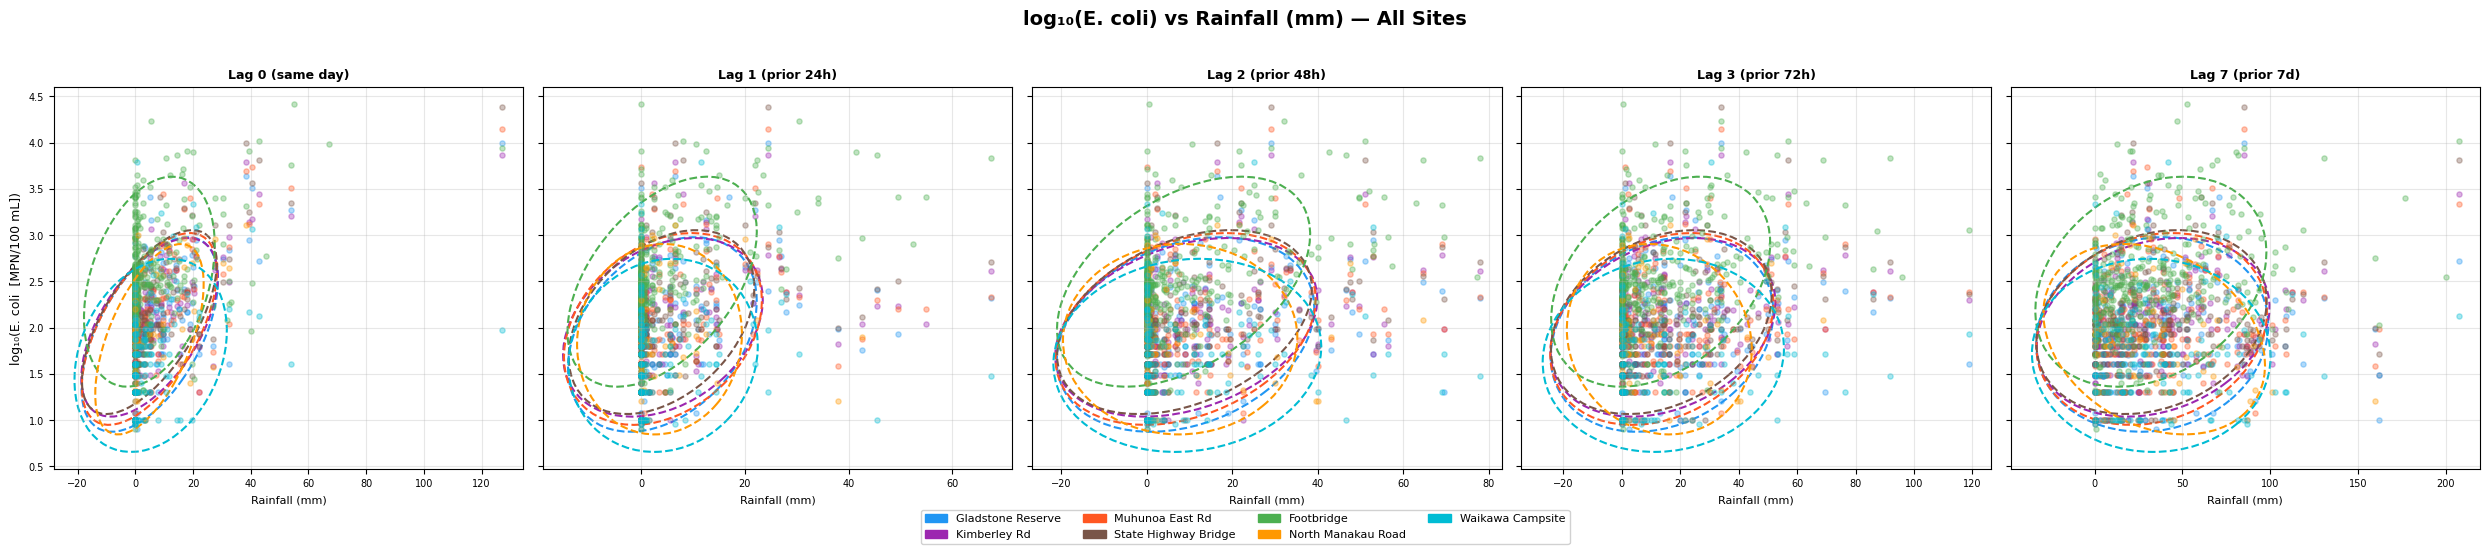

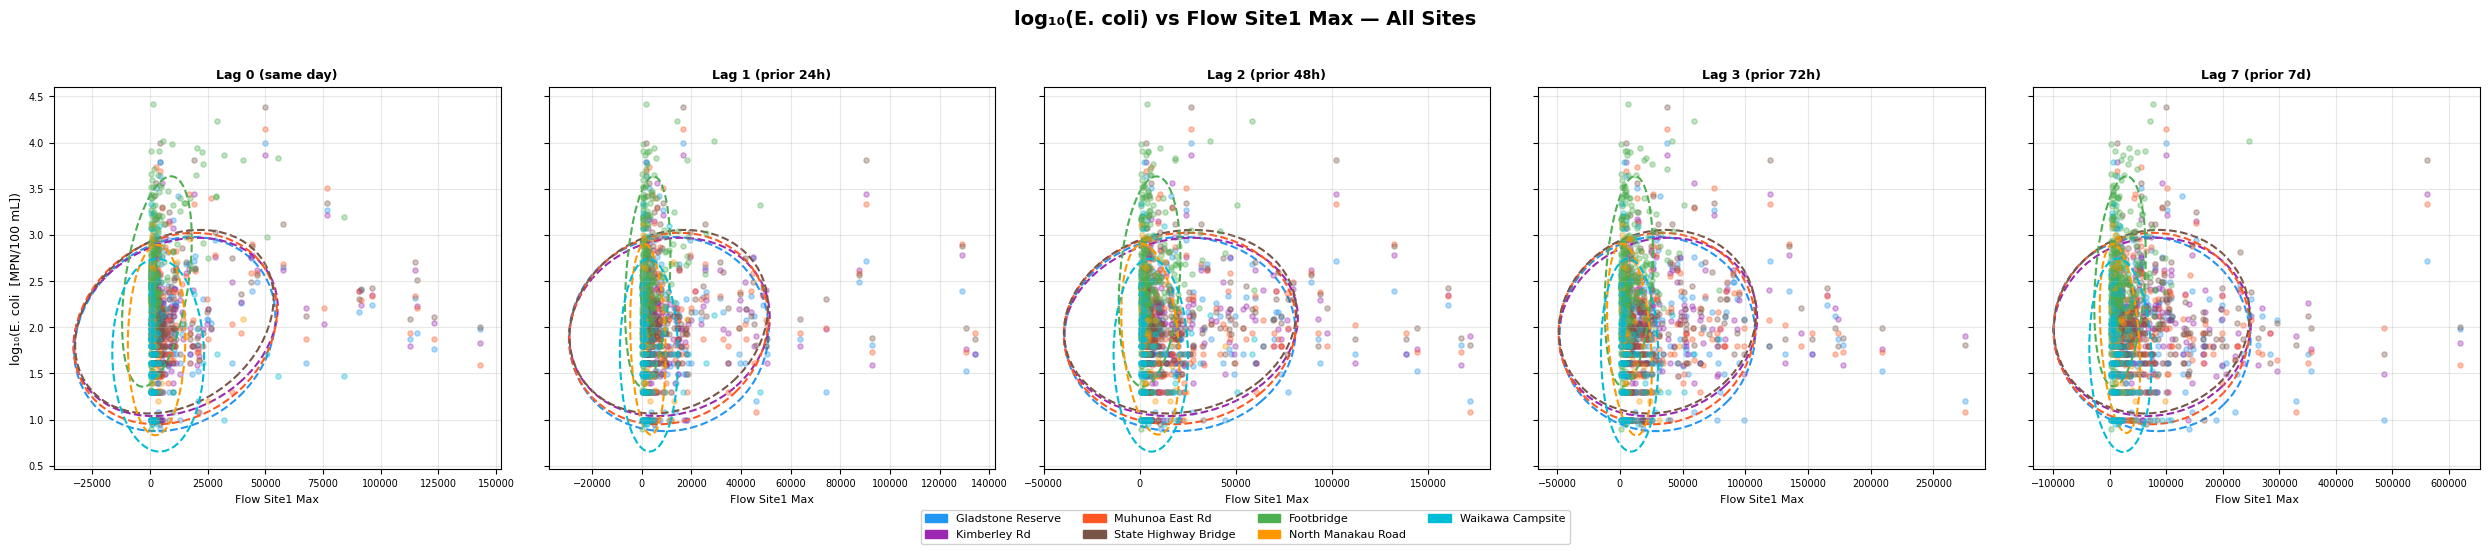

Generating Figure 2: Per-site scatter grids …


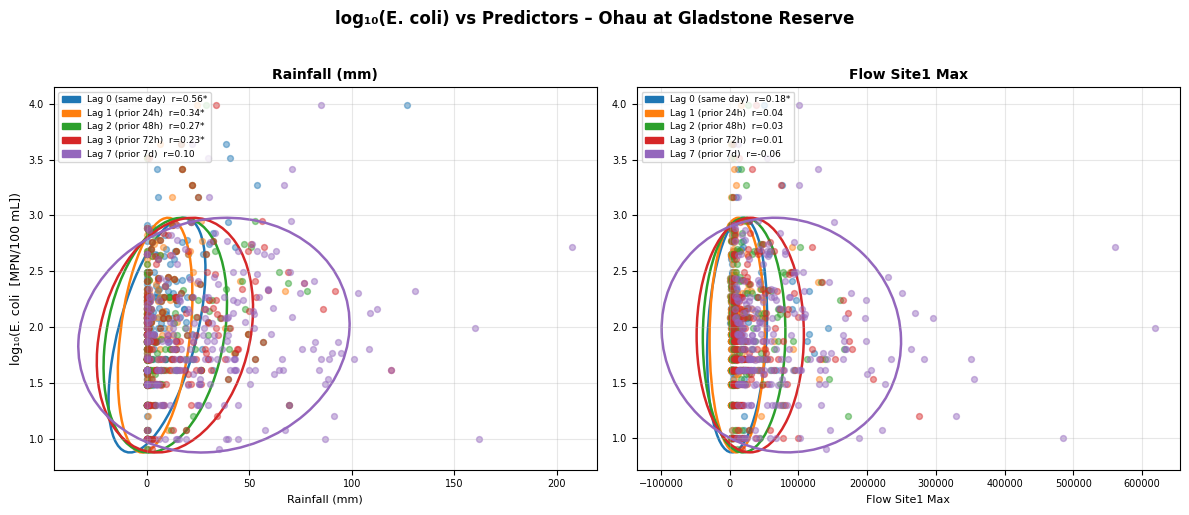

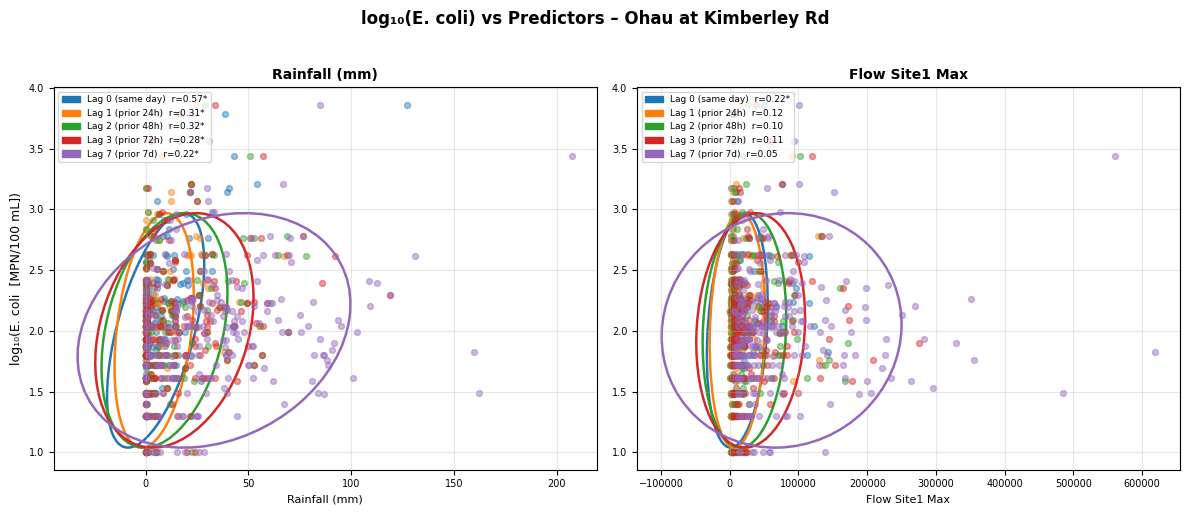

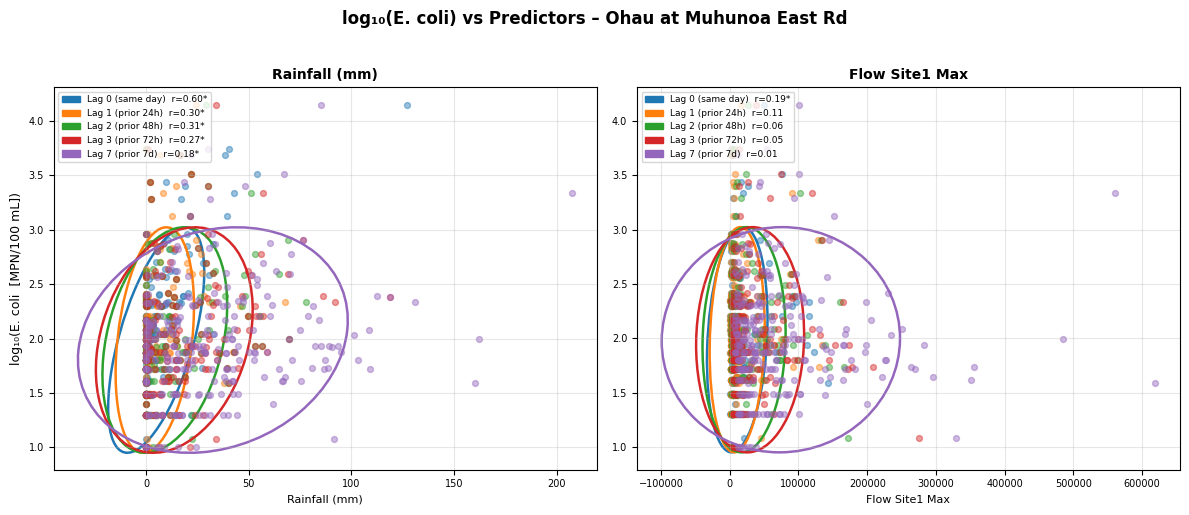

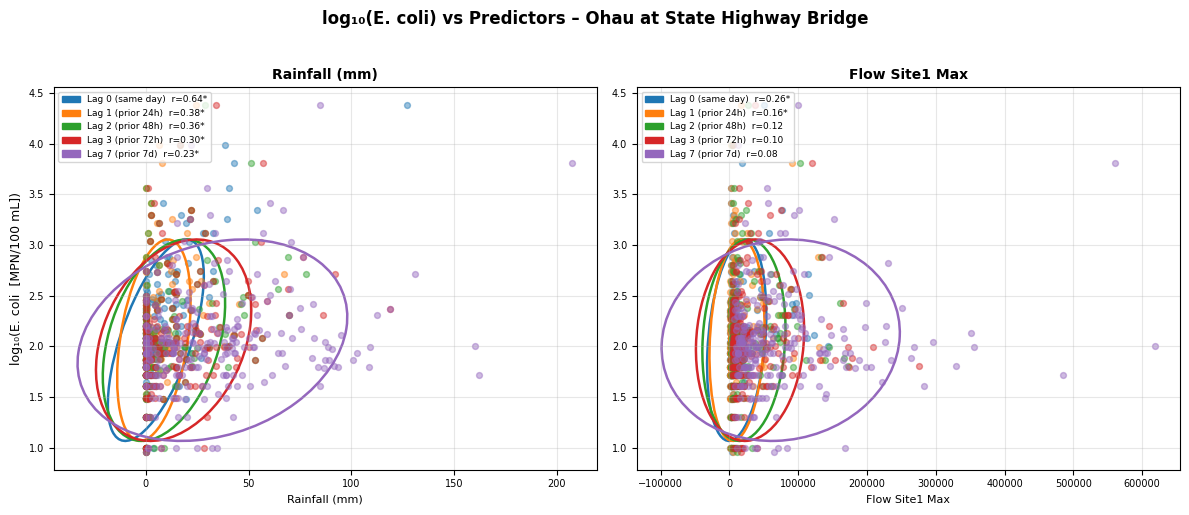

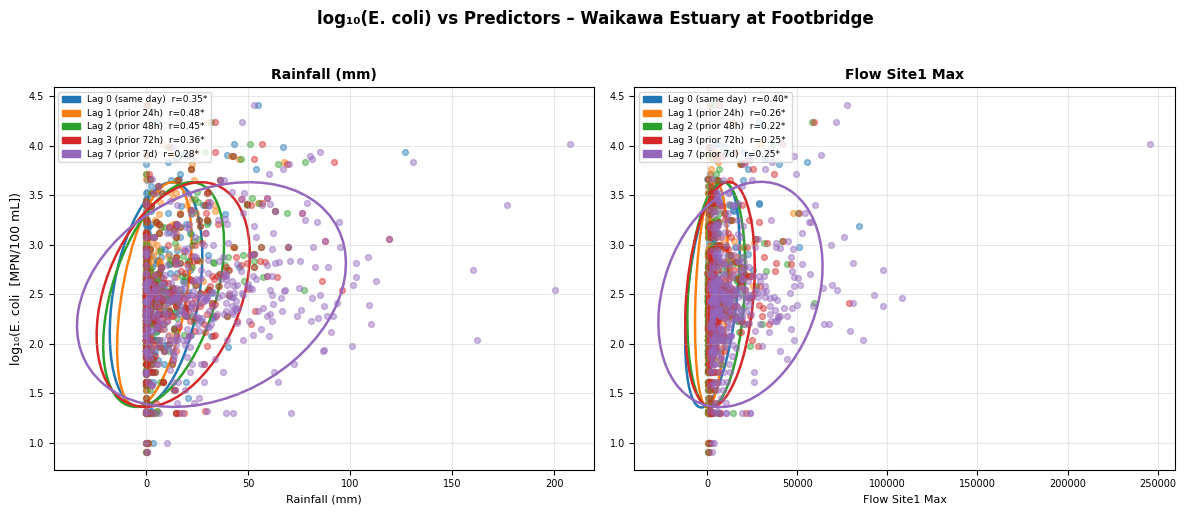

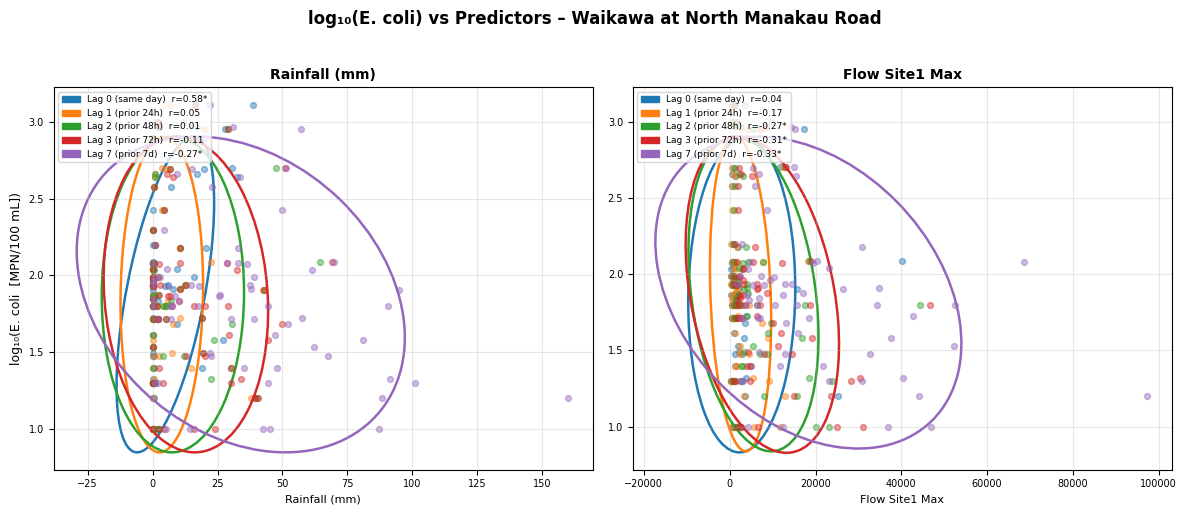

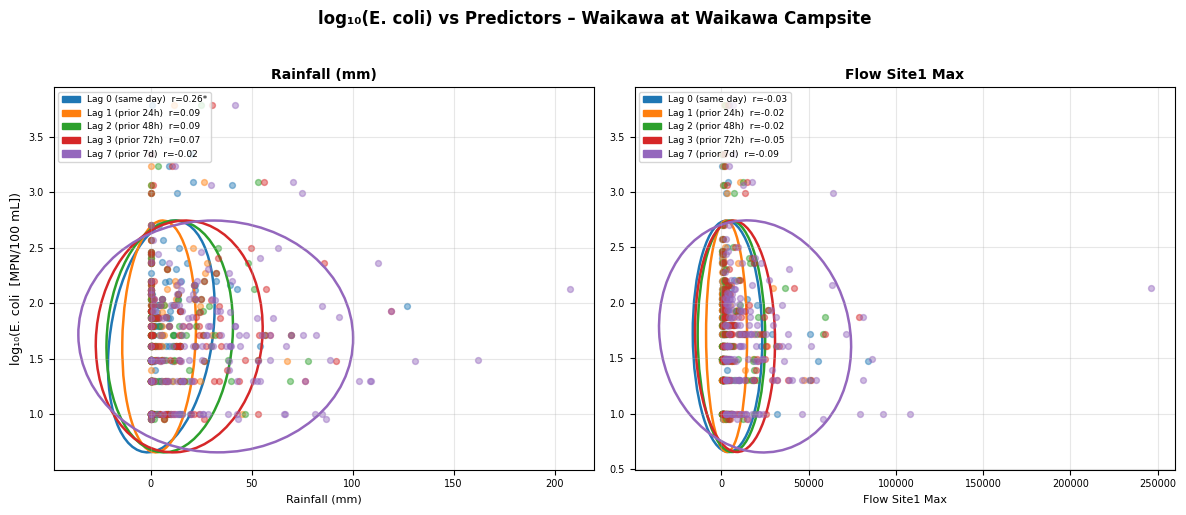

Generating Figure 3: Correlation heatmap …


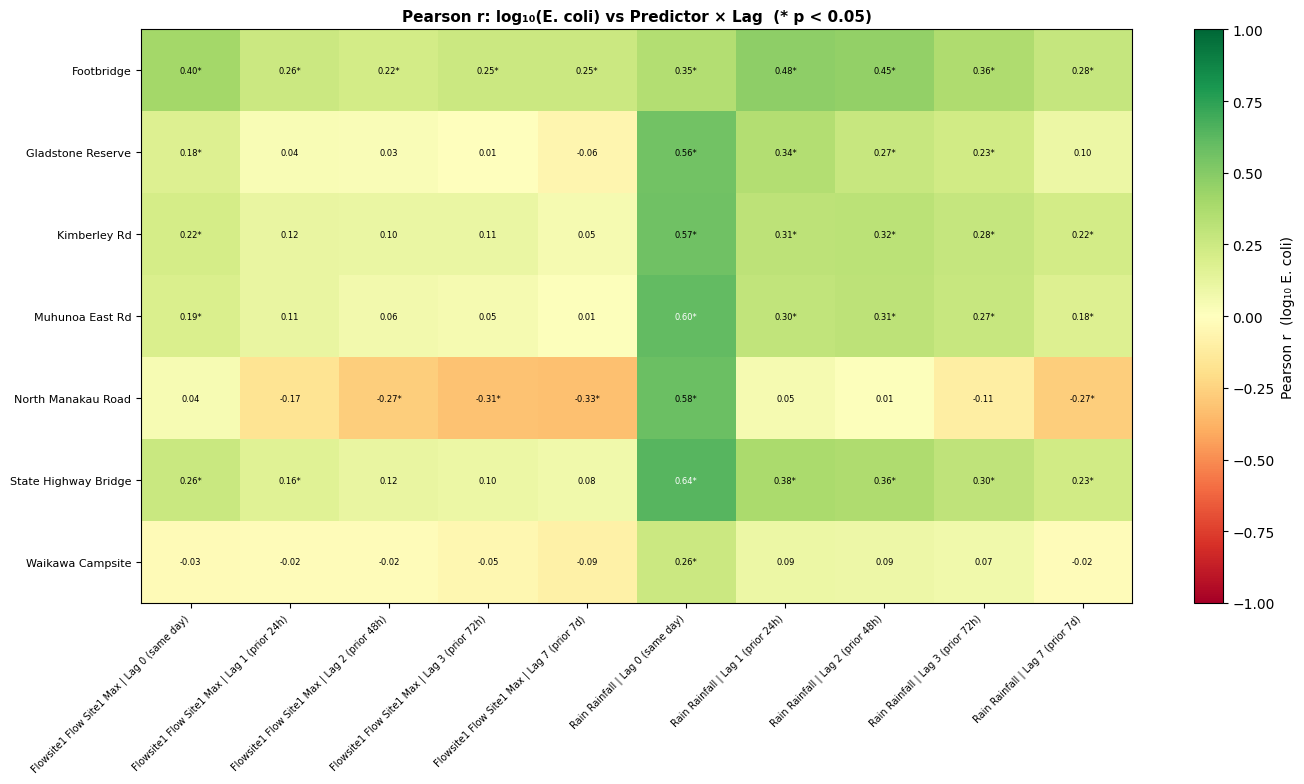

Generating Figure 4: Cross-correlation bar charts – Waikawa …


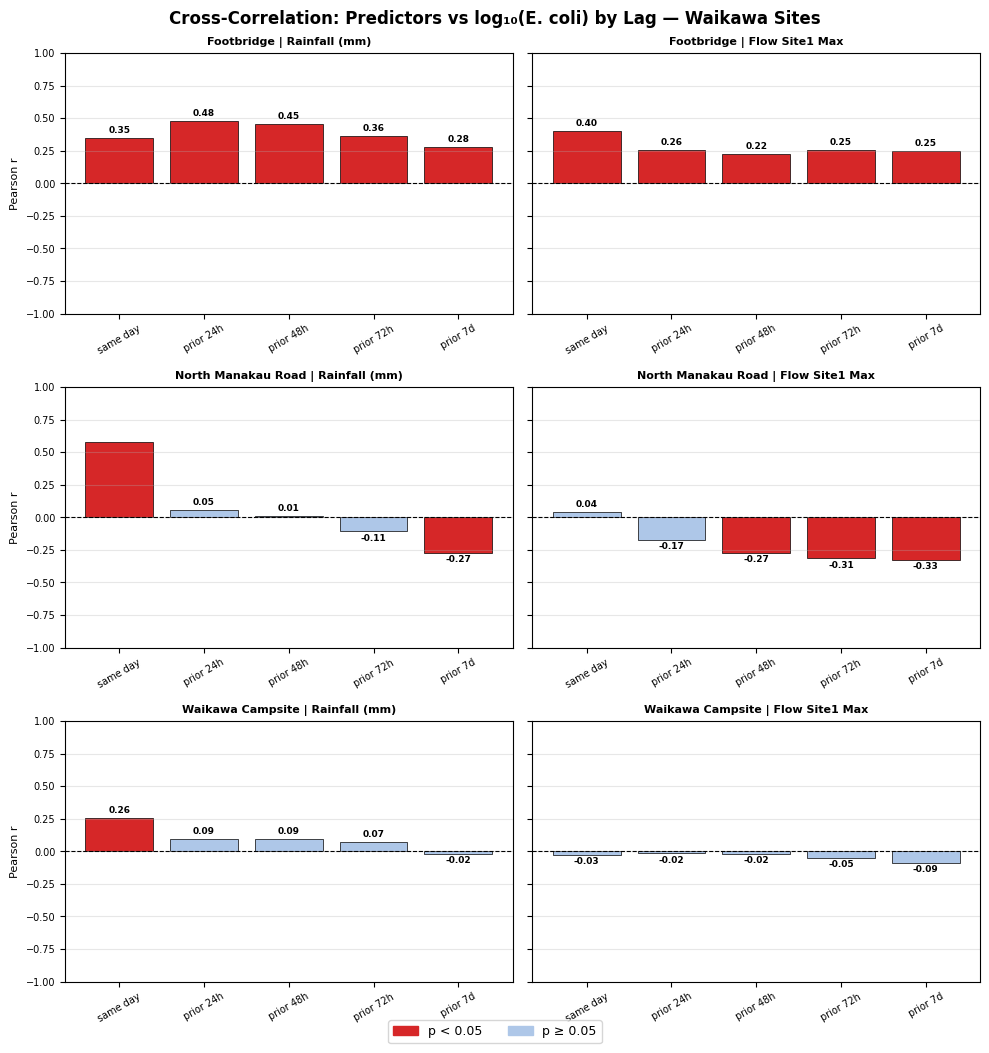

Generating Figure 5: Seasonal boxplots …


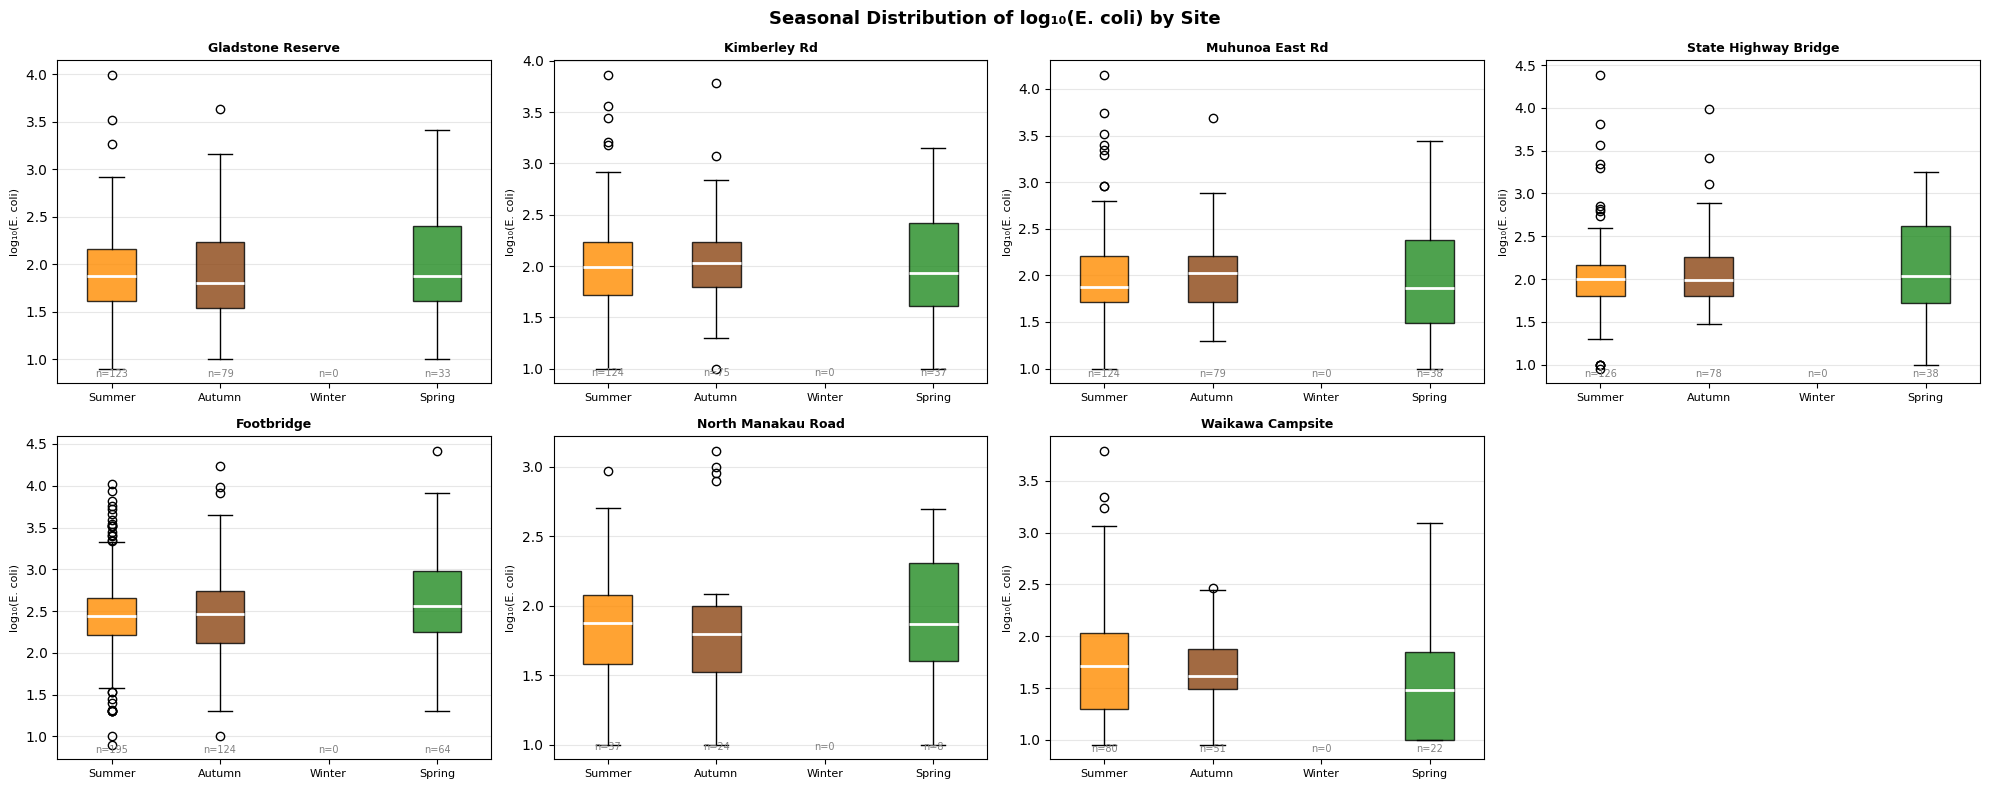

Generating Figure 6: Time series – Waikawa …


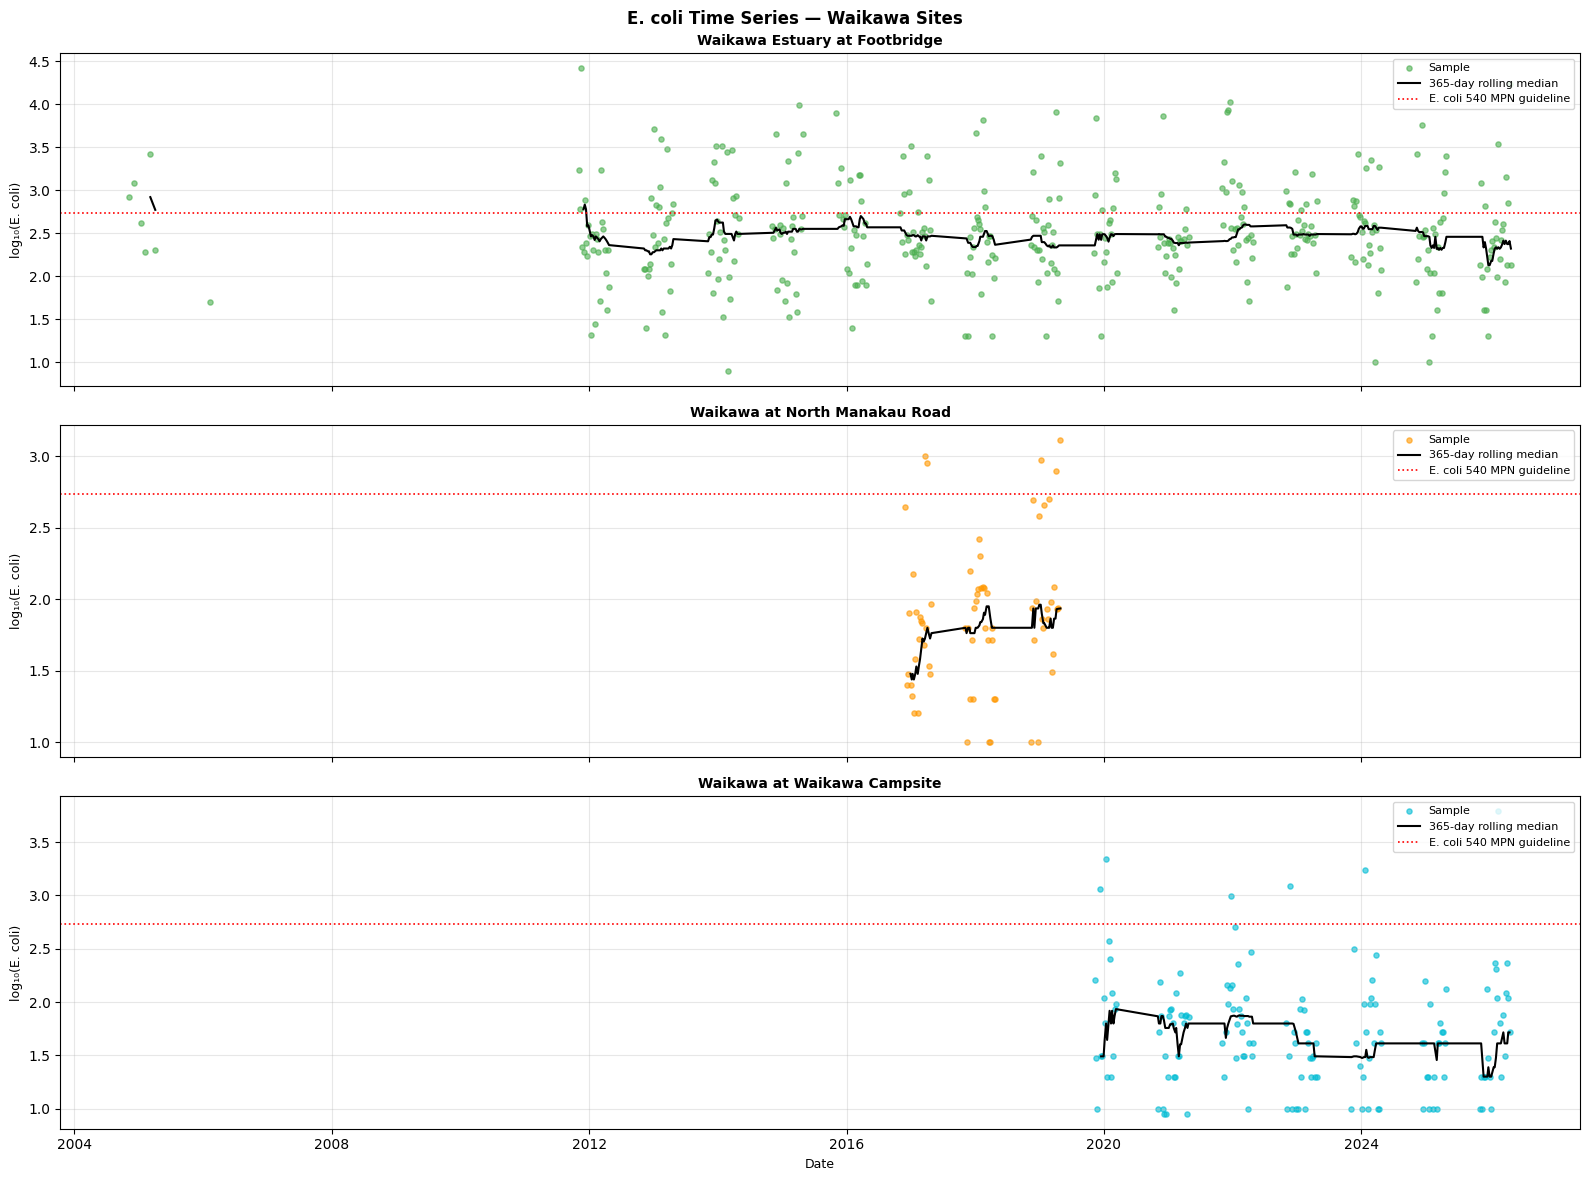

Generating Figure 7: PCA biplot …


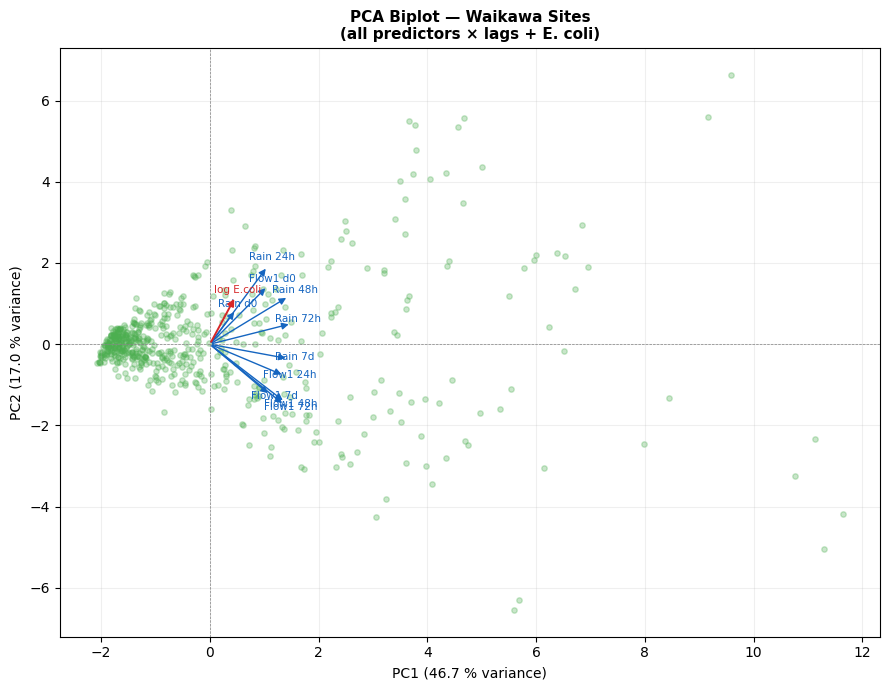

Generating Figure 8: Exceedance frequency …


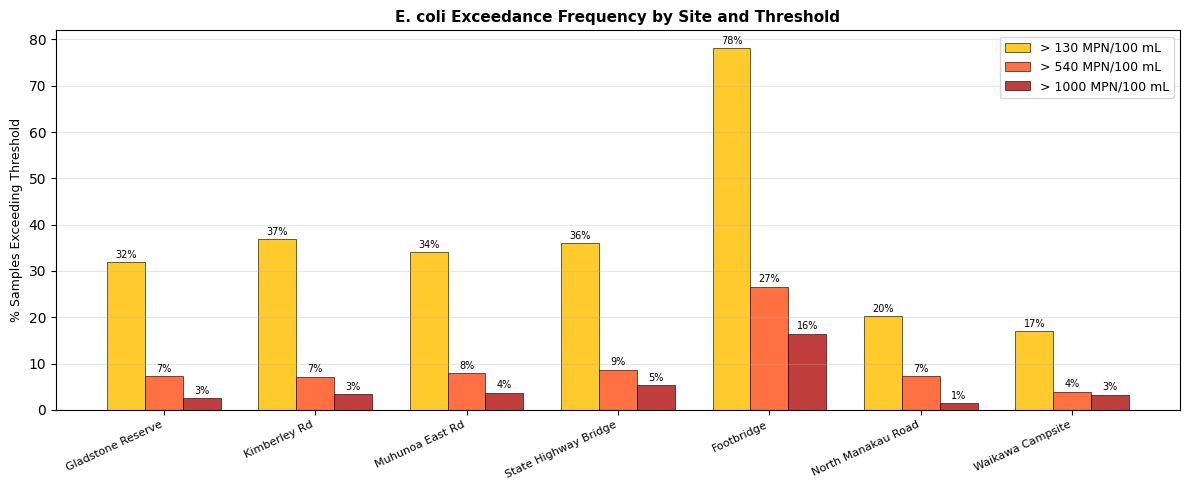

Generating Figure 9: 7-day antecedent rainfall vs E. coli – Waikawa …


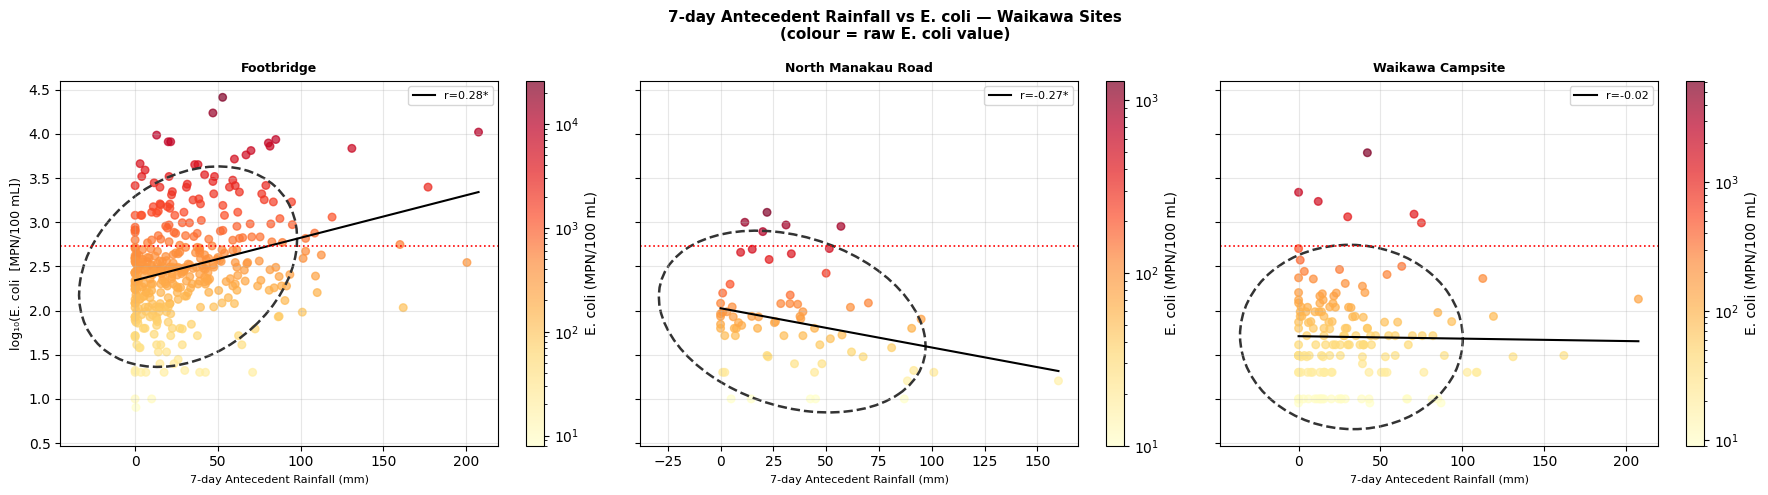

Generating Figure 10: Best-lag summary table …


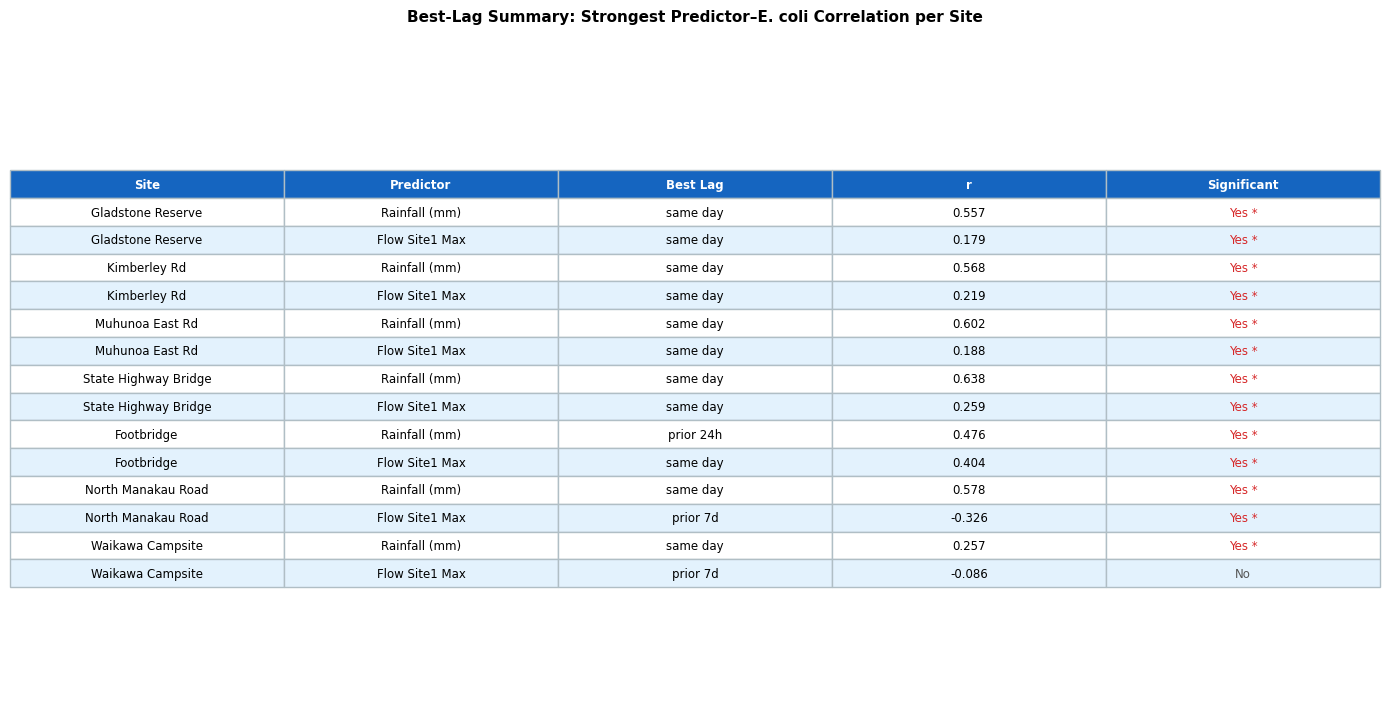


✅  All 10 figures saved to: /content/Figures
 • fig1_Rainfall_mm_scatter_all_sites.png
 • fig1_Flow_Site1_Max_scatter_all_sites.png
 • fig1_Flow_Site2_Max_scatter_all_sites.png
 • fig2_*_per_predictor_lags.png  (one per site)
 • fig3_correlation_heatmap.png
 • fig4_crosscorrelation_waikawa.png
 • fig5_seasonal_boxplots.png
 • fig6_timeseries_waikawa.png
 • fig7_pca_biplot_waikawa.png
 • fig8_exceedance_frequency.png
 • fig9_7d_rainfall_ecoli_waikawa.png
 • fig10_best_lag_summary_table.png


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from matplotlib.gridspec import GridSpec
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os

# __ paths ______________________________________________________________________
DATA_PATH = "/content/master_ecoli_rf_flow.csv"
OUT_DIR = "/content/Figures"
os.makedirs(OUT_DIR, exist_ok=True)

# __ palette ____________________________________________________________________
SITE_COLORS = {
    "Ohau at Gladstone Reserve":      "#2196F3",
    "Ohau at Kimberley Rd":           "#9C27B0",
    "Ohau at Muhunoa East Rd":        "#FF5722",
    "Ohau at State Highway Bridge":   "#795548",
    "Waikawa Estuary at Footbridge":  "#4CAF50",
    "Waikawa at North Manakau Road":  "#FF9800",
    "Waikawa at Waikawa Campsite":    "#00BCD4",
}
LAG_COLORS = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd"]

# __ lag mapping (already encoded in columns) ___________________________________
LAGS = {
    "Lag 0 (same day)":  "day0",
    "Lag 1 (prior 24h)": "prior24h",
    "Lag 2 (prior 48h)": "prior48h",
    "Lag 3 (prior 72h)": "prior72h",
    "Lag 7 (prior 7d)":  "prior7d",
}

PREDICTORS = {
    "Rainfall (mm)":      "rain_mm",
    "Flow Site1 Max":     "flowsite1_max",
  #  "Flow Site2 Max":     "flowsite2_max",
}

# __ load & clean _______________________________________________________________
df = pd.read_excel(DATA_PATH, parse_dates=["date"])
df = df.dropna(subset=["ecoli_value"])
df = df[df["ecoli_value"] > 0].copy()

df["log_ecoli"] = np.log10(df["ecoli_value"])
df["month"]     = df["date"].dt.month
df["season"]    = df["month"].map({
    12:"Summer",1:"Summer",2:"Summer",
    3:"Autumn", 4:"Autumn", 5:"Autumn",
    6:"Winter", 7:"Winter", 8:"Winter",
    9:"Spring",10:"Spring",11:"Spring"
})
df["year"] = df["date"].dt.year

SITES = df["sitename"].unique().tolist()
WAIKAWA = [s for s in SITES if "Waikawa" in s]

# ===============================================================================
# helper: 95 % confidence ellipse
# ===============================================================================
def confidence_ellipse(x, y, ax, n_std=2.0, facecolor="none", **kwargs):
    if len(x) < 5:
        return
    cov = np.cov(x, y)
    pearson = cov[0,1] / (np.sqrt(cov[0,0]) * np.sqrt(cov[1,1]) + 1e-12)
    rx = np.sqrt(1 + pearson)
    ry = np.sqrt(1 - pearson)
    ell = Ellipse((0,0), width=rx*2, height=ry*2, facecolor=facecolor, **kwargs)
    sx = np.sqrt(cov[0,0]) * n_std
    sy = np.sqrt(cov[1,1]) * n_std
    t = transforms.Affine2D().rotate_deg(45).scale(sx, sy).translate(np.mean(x), np.mean(y))
    ell.set_transform(t + ax.transData)
    ax.add_patch(ell)

def safe_r(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5:
        return np.nan, np.nan
    r, p = stats.pearsonr(x[mask], y[mask])
    return r, p

# ===============================================================================
# FIGURE 1 – Scatter plots per predictor × lag  (all sites overlaid, log E. coli)
# ===============================================================================
print("Generating Figure 1: Scatter plots – all sites, per predictor × lag …")

for pred_name, pred_key in PREDICTORS.items():
    n_lags = len(LAGS)
    fig, axes = plt.subplots(1, n_lags, figsize=(5*n_lags, 5), sharey=True)
    fig.suptitle(f"log₁₀(E. coli) vs {pred_name} — All Sites", fontsize=14, fontweight="bold", y=1.02)

    for ax, (lag_name, lag_key) in zip(axes, LAGS.items()):
        col = f"{pred_key}_{lag_key}"
        if col not in df.columns:
            ax.set_visible(False)
            continue

        for site in SITES:
            sub = df[df["sitename"] == site][[col, "log_ecoli"]].dropna()
            x = sub[col].values
            y = sub["log_ecoli"].values
            c = SITE_COLORS[site]
            ax.scatter(x, y, alpha=0.35, s=14, color=c, label=site.split(" at ")[-1])
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() >= 5:
                confidence_ellipse(x[mask], y[mask], ax, n_std=2,
                                   edgecolor=c, linewidth=1.5, linestyle="--")

        ax.set_title(lag_name, fontsize=9, fontweight="bold")
        ax.set_xlabel(pred_name, fontsize=8)
        if ax == axes[0]:
            ax.set_ylabel("log₁₀(E. coli  [MPN/100 mL])", fontsize=9)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)

    handles = [mpatches.Patch(color=SITE_COLORS[s],
                               label=s.split(" at ")[-1]) for s in SITES]
    fig.legend(handles=handles, loc="lower center", ncol=4,
               bbox_to_anchor=(0.5,-0.06), fontsize=8, framealpha=0.9)
    fig.tight_layout()
    safe_name = pred_name.replace(" ","_").replace("(","").replace(")","").replace("/","")
    # fig.savefig(f"{OUT_DIR}/fig1_{safe_name}_scatter_all_sites.png",
    #             dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# ===============================================================================
# FIGURE 2 – Per-site scatter grid  (site × predictor, all lags colour-coded)
# ===============================================================================
print("Generating Figure 2: Per-site scatter grids …")

for site in SITES:
    sub_site = df[df["sitename"] == site].copy()
    n_pred   = len(PREDICTORS)
    fig, axes = plt.subplots(1, n_pred, figsize=(6*n_pred, 5))
    fig.suptitle(f"log₁₀(E. coli) vs Predictors – {site}", fontsize=12,
                 fontweight="bold", y=1.02)

    for ax, (pred_name, pred_key) in zip(axes, PREDICTORS.items()):
        lag_handles = []
        for i, (lag_name, lag_key) in enumerate(LAGS.items()):
            col = f"{pred_key}_{lag_key}"
            if col not in sub_site.columns:
                continue
            xy = sub_site[[col,"log_ecoli"]].dropna()
            x  = xy[col].values
            y  = xy["log_ecoli"].values
            c  = LAG_COLORS[i]
            ax.scatter(x, y, alpha=0.45, s=18, color=c, label=lag_name)
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() >= 5:
                confidence_ellipse(x[mask], y[mask], ax, n_std=2,
                                   edgecolor=c, linewidth=1.8, linestyle="-")
                r, p = safe_r(x, y)
                if not np.isnan(r):
                    lag_handles.append(mpatches.Patch(color=c,
                        label=f"{lag_name}  r={r:.2f}{'*' if p<0.05 else ''}"))

        ax.set_title(pred_name, fontsize=10, fontweight="bold")
        ax.set_xlabel(pred_name, fontsize=8)
        if ax == axes[0]:
            ax.set_ylabel("log₁₀(E. coli  [MPN/100 mL])", fontsize=9)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
        ax.legend(handles=lag_handles, fontsize=6.5, loc="upper left", framealpha=0.8)

    fig.tight_layout()
    safe = site.replace(" ","_").replace("/","")
    # fig.savefig(f"{OUT_DIR}/fig2_{safe}_per_predictor_lags.png",
    #             dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# ===============================================================================
# FIGURE 3 – Correlation heatmap: |r| across sites × (predictor × lag)
# ===============================================================================
print("Generating Figure 3: Correlation heatmap …")

records = []
for site in SITES:
    sub = df[df["sitename"] == site]
    for pred_name, pred_key in PREDICTORS.items():
        for lag_name, lag_key in LAGS.items():
            col = f"{pred_key}_{lag_key}"
            if col not in sub.columns:
                continue
            xy = sub[[col,"log_ecoli"]].dropna()
            r, p = safe_r(xy[col].values, xy["log_ecoli"].values)
            records.append({
                "site":      site.split(" at ")[-1],
                "predictor": f"{pred_key.split('_')[0].capitalize()} {pred_name.split('(')[0].strip()}",
                "lag":       lag_name,
                "r":         r,
                "p":         p,
            })

corr_df = pd.DataFrame(records)
corr_df["combo"] = corr_df["predictor"] + " | " + corr_df["lag"]

pivot = corr_df.pivot_table(index="site", columns="combo", values="r")
pivot_p = corr_df.pivot_table(index="site", columns="combo", values="p")

fig, ax = plt.subplots(figsize=(max(14, len(pivot.columns)*0.9), len(SITES)*0.85 + 2))
im = ax.imshow(pivot.values.astype(float), aspect="auto",
               cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Pearson r  (log₁₀ E. coli)")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        pv  = pivot_p.values[i, j]
        if not np.isnan(val):
            sig = "*" if (not np.isnan(pv) and pv < 0.05) else ""
            ax.text(j, i, f"{val:.2f}{sig}", ha="center", va="center",
                    fontsize=6, color="black" if abs(val) < 0.6 else "white")

ax.set_title("Pearson r: log₁₀(E. coli) vs Predictor × Lag  (* p < 0.05)",
             fontsize=11, fontweight="bold")
fig.tight_layout()
# fig.savefig(f"{OUT_DIR}/fig3_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# ===============================================================================
# FIGURE 4 – Cross-correlation bar chart per predictor (Waikawa focus)
# ===============================================================================
print("Generating Figure 4: Cross-correlation bar charts – Waikawa …")

fig, axes = plt.subplots(len(WAIKAWA), len(PREDICTORS),
                          figsize=(5*len(PREDICTORS), 3.5*len(WAIKAWA)), sharey="row")
if len(WAIKAWA) == 1:
    axes = axes[np.newaxis, :]

for row, site in enumerate(WAIKAWA):
    sub = df[df["sitename"] == site]
    for col_i, (pred_name, pred_key) in enumerate(PREDICTORS.items()):
        ax = axes[row, col_i]
        rs, ps, labels = [], [], []
        for lag_name, lag_key in LAGS.items():
            col = f"{pred_key}_{lag_key}"
            if col not in sub.columns:
                continue
            xy = sub[[col,"log_ecoli"]].dropna()
            r, p = safe_r(xy[col].values, xy["log_ecoli"].values)
            rs.append(r); ps.append(p); labels.append(lag_name.split("(")[1].rstrip(")"))

        bar_colors = ["#d62728" if p<0.05 else "#aec7e8" for p in ps]
        bars = ax.bar(labels, rs, color=bar_colors, edgecolor="k", linewidth=0.5)
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_ylim(-1, 1)
        ax.set_ylabel("Pearson r", fontsize=8) if col_i == 0 else None
        ax.set_title(f"{site.split(' at ')[-1]} | {pred_name}", fontsize=8, fontweight="bold")
        ax.tick_params(axis="x", labelsize=7, rotation=30)
        ax.tick_params(axis="y", labelsize=7)
        ax.grid(axis="y", alpha=0.3)
        for bar, r, p in zip(bars, rs, ps):
            if not np.isnan(r):
                ax.text(bar.get_x()+bar.get_width()/2, r + (0.04 if r>=0 else -0.07),
                        f"{r:.2f}", ha="center", fontsize=6.5,
                        color="white" if abs(r)>0.5 else "black", fontweight="bold")

red_patch  = mpatches.Patch(color="#d62728", label="p < 0.05")
blue_patch = mpatches.Patch(color="#aec7e8", label="p ≥ 0.05")
fig.legend(handles=[red_patch, blue_patch], loc="lower center", ncol=2,
           bbox_to_anchor=(0.5,-0.01), fontsize=9)
fig.suptitle("Cross-Correlation: Predictors vs log₁₀(E. coli) by Lag — Waikawa Sites",
             fontsize=12, fontweight="bold")
fig.tight_layout()
# fig.savefig(f"{OUT_DIR}/fig4_crosscorrelation_waikawa.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# ===============================================================================
# FIGURE 5 – Seasonal boxplots of E. coli per site
# ===============================================================================
print("Generating Figure 5: Seasonal boxplots …")

season_order = ["Summer","Autumn","Winter","Spring"]
season_colors = {"Summer":"#FF8C00","Autumn":"#8B4513","Winter":"#1E90FF","Spring":"#228B22"}

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, site in enumerate(SITES):
    ax = axes[i]
    sub = df[df["sitename"] == site]
    data_by_season = [sub[sub["season"]==s]["log_ecoli"].dropna().values
                      for s in season_order]
    bp = ax.boxplot(data_by_season, patch_artist=True, notch=False,
                    medianprops=dict(color="white", linewidth=2))
    for patch, s in zip(bp["boxes"], season_order):
        patch.set_facecolor(season_colors[s])
        patch.set_alpha(0.8)
    ax.set_xticklabels(season_order, fontsize=8)
    ax.set_title(site.split(" at ")[-1], fontsize=9, fontweight="bold")
    ax.set_ylabel("log₁₀(E. coli)", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    for j, (s, vals) in enumerate(zip(season_order, data_by_season)):
        ax.text(j+1, ax.get_ylim()[0]+0.05, f"n={len(vals)}",
                ha="center", va="bottom", fontsize=7, color="grey")

for ax in axes[len(SITES):]:
    ax.set_visible(False)

fig.suptitle("Seasonal Distribution of log₁₀(E. coli) by Site", fontsize=13, fontweight="bold")
fig.tight_layout()
# fig.savefig(f"{OUT_DIR}/fig5_seasonal_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# ===============================================================================
# FIGURE 6 – Time series with rolling median (Waikawa sites)
# ===============================================================================
print("Generating Figure 6: Time series – Waikawa …")

fig, axes = plt.subplots(len(WAIKAWA), 1, figsize=(16, 4*len(WAIKAWA)), sharex=True)
if len(WAIKAWA) == 1:
    axes = [axes]

for ax, site in zip(axes, WAIKAWA):
    sub = df[df["sitename"] == site].sort_values("date")
    ax.scatter(sub["date"], sub["log_ecoli"], color=SITE_COLORS[site],
               s=14, alpha=0.6, label="Sample")
    roll = sub.set_index("date")["log_ecoli"].rolling("365D", min_periods=5).median()
    ax.plot(roll.index, roll.values, color="black", linewidth=1.5,
            label="365-day rolling median")
    ax.axhline(np.log10(540), color="red", linewidth=1.2, linestyle=":",
               label="E. coli 540 MPN guideline")
    ax.set_ylabel("log₁₀(E. coli)", fontsize=9)
    ax.set_title(site, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date", fontsize=9)
fig.suptitle("E. coli Time Series — Waikawa Sites", fontsize=12, fontweight="bold")
fig.tight_layout()
# fig.savefig(f"{OUT_DIR}/fig6_timeseries_waikawa.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# ===============================================================================
# FIGURE 7 – PCA biplot (Waikawa, lag-0 features)
# ===============================================================================
print("Generating Figure 7: PCA biplot …")

pca_cols = [
    "rain_mm_day0","rain_mm_prior24h","rain_mm_prior48h","rain_mm_prior72h","rain_mm_prior7d",
    "flowsite1_max_day0","flowsite1_max_prior24h","flowsite1_max_prior48h",
    "flowsite1_max_prior72h","flowsite1_max_prior7d",
    "log_ecoli",
]
pca_labels = [
    "Rain d0","Rain 24h","Rain 48h","Rain 72h","Rain 7d",
    "Flow1 d0","Flow1 24h","Flow1 48h","Flow1 72h","Flow1 7d",
    "log E.coli",
]

wk = df[df["sitename"].str.contains("Waikawa")][pca_cols].dropna()
X  = StandardScaler().fit_transform(wk)
pca = PCA(n_components=2)
scores = pca.fit_transform(X)
loadings = pca.components_

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(scores[:,0], scores[:,1], alpha=0.3, s=15, color="#4CAF50")

scale = 4
for i, label in enumerate(pca_labels):
    dx, dy = loadings[0,i]*scale, loadings[1,i]*scale
    ax.annotate("", xy=(dx,dy), xytext=(0,0),
                arrowprops=dict(arrowstyle="-|>", color="#d62728" if "coli" in label else "#1565C0",
                                lw=1.4 if "coli" in label else 1.0))
    ax.text(dx*1.08, dy*1.08, label, fontsize=7.5,
            color="#d62728" if "coli" in label else "#1565C0", ha="center")

var1, var2 = pca.explained_variance_ratio_*100
ax.set_xlabel(f"PC1 ({var1:.1f} % variance)", fontsize=10)
ax.set_ylabel(f"PC2 ({var2:.1f} % variance)", fontsize=10)
ax.set_title("PCA Biplot — Waikawa Sites\n(all predictors × lags + E. coli)", fontsize=11, fontweight="bold")
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
ax.grid(alpha=0.2)
fig.tight_layout()
# fig.savefig(f"{OUT_DIR}/fig7_pca_biplot_waikawa.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# ===============================================================================
# FIGURE 8 – Exceedance frequency analysis
# ===============================================================================
print("Generating Figure 8: Exceedance frequency …")

THRESHOLDS = [130, 540, 1000]
thresh_colors = ["#FFC107","#FF5722","#B71C1C"]

exc_records = []
for site in SITES:
    sub = df[df["sitename"] == site]
    for t in THRESHOLDS:
        pct = (sub["ecoli_value"] > t).mean() * 100
        exc_records.append({"site": site.split(" at ")[-1], "threshold": t, "pct": pct})

exc_df = pd.DataFrame(exc_records)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(SITES))
width = 0.25
for i, (t, c) in enumerate(zip(THRESHOLDS, thresh_colors)):
    vals = exc_df[exc_df["threshold"]==t]["pct"].values
    bars = ax.bar(x + (i-1)*width, vals, width, label=f"> {t} MPN/100 mL",
                  color=c, alpha=0.85, edgecolor="k", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f"{v:.0f}%",
                ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([s.split(" at ")[-1] for s in SITES], rotation=25, ha="right", fontsize=8)
ax.set_ylabel("% Samples Exceeding Threshold", fontsize=9)
ax.set_title("E. coli Exceedance Frequency by Site and Threshold", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
# fig.savefig(f"{OUT_DIR}/fig8_exceedance_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# ===============================================================================
# FIGURE 9 – Rain event scatter: antecedent 7-day rainfall vs E. coli, Waikawa
# ===============================================================================
print("Generating Figure 9: 7-day antecedent rainfall vs E. coli – Waikawa …")

fig, axes = plt.subplots(1, len(WAIKAWA), figsize=(6*len(WAIKAWA), 5), sharey=True)
if len(WAIKAWA) == 1:
    axes = [axes]

for ax, site in zip(axes, WAIKAWA):
    sub = df[df["sitename"]==site][["rain_mm_prior7d","log_ecoli","ecoli_value"]].dropna()
    x = sub["rain_mm_prior7d"].values
    y = sub["log_ecoli"].values
    sc = ax.scatter(x, y, c=sub["ecoli_value"].values, cmap="YlOrRd",
                    s=30, alpha=0.7, norm=matplotlib.colors.LogNorm())
    plt.colorbar(sc, ax=ax, label="E. coli (MPN/100 mL)")
    if len(x) >= 5:
        confidence_ellipse(x, y, ax, n_std=2, edgecolor="#333",
                           linewidth=1.8, linestyle="--")
        m, b, r, p, _ = stats.linregress(x, y)
        xl = np.linspace(x.min(), x.max(), 100)
        ax.plot(xl, m*xl+b, color="black", linewidth=1.5,
                label=f"r={r:.2f}{'*' if p<0.05 else ''}")
        ax.legend(fontsize=8)
    ax.axhline(np.log10(540), color="red", linestyle=":", linewidth=1.2, label="540 MPN")
    ax.set_title(site.split(" at ")[-1], fontsize=9, fontweight="bold")
    ax.set_xlabel("7-day Antecedent Rainfall (mm)", fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel("log₁₀(E. coli  [MPN/100 mL])", fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle("7-day Antecedent Rainfall vs E. coli — Waikawa Sites\n(colour = raw E. coli value)",
             fontsize=11, fontweight="bold")
fig.tight_layout()
# fig.savefig(f"{OUT_DIR}/fig9_7d_rainfall_ecoli_waikawa.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# ===============================================================================
# FIGURE 10 – Best-lag summary table as figure
# ===============================================================================
print("Generating Figure 10: Best-lag summary table …")

summary = []
for site in SITES:
    sub = df[df["sitename"]==site]
    for pred_name, pred_key in PREDICTORS.items():
        best_r, best_lag, best_p = 0, "", 1
        for lag_name, lag_key in LAGS.items():
            col = f"{pred_key}_{lag_key}"
            if col not in sub.columns:
                continue
            xy = sub[[col,"log_ecoli"]].dropna()
            r, p = safe_r(xy[col].values, xy["log_ecoli"].values)
            if not np.isnan(r) and abs(r) > abs(best_r):
                best_r, best_lag, best_p = r, lag_name, p
        summary.append({
            "Site": site.split(" at ")[-1],
            "Predictor": pred_name,
            "Best Lag": best_lag.split("(")[1].rstrip(")") if best_lag else "N/A",
            "r": f"{best_r:.3f}" if best_r else "N/A",
            "Significant": "Yes *" if best_p < 0.05 else "No",
        })

sum_df = pd.DataFrame(summary)

fig, ax = plt.subplots(figsize=(14, len(summary)*0.42 + 1.5))
ax.axis("off")
tbl = ax.table(
    cellText=sum_df.values, colLabels=sum_df.columns,
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.4)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#1565C0")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#E3F2FD")
    else:
        cell.set_facecolor("white")
    cell.set_edgecolor("#B0BEC5")
    if col == 4 and row > 0:
        cell.set_text_props(color="#d62728" if "Yes" in str(cell.get_text().get_text()) else "#555")

ax.set_title("Best-Lag Summary: Strongest Predictor–E. coli Correlation per Site",
             fontsize=11, fontweight="bold", pad=14)
fig.tight_layout()
# fig.savefig(f"{OUT_DIR}/fig10_best_lag_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# __ done _______________________________________________________________________
print("\n✅  All 10 figures saved to:", OUT_DIR)
outputs = [
    "fig1_Rainfall_mm_scatter_all_sites.png",
    "fig1_Flow_Site1_Max_scatter_all_sites.png",
    "fig1_Flow_Site2_Max_scatter_all_sites.png",
    "fig2_*_per_predictor_lags.png  (one per site)",
    "fig3_correlation_heatmap.png",
    "fig4_crosscorrelation_waikawa.png",
    "fig5_seasonal_boxplots.png",
    "fig6_timeseries_waikawa.png",
    "fig7_pca_biplot_waikawa.png",
    "fig8_exceedance_frequency.png",
    "fig9_7d_rainfall_ecoli_waikawa.png",
    "fig10_best_lag_summary_table.png",
]
for o in outputs:
    print(" •", o)